# The humanoid

Every board a node, every node a joint; a small model reads a short card and answers with lines the sequencer runs.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 The nodes

`Nodes.discover` asks every bus for its nodes and opens each on its own; a node is named where it sits. What each offers comes before anything is configured.

In [3]:
from coaxial.nodes import Nodes

nodes = Nodes.discover(port=PORT, device=SIMULATED)
print('%d nodes: %s' % (len(nodes), ', '.join(n.name for n in nodes)))
print(nodes.card('angle', 'drive', keys=('degrees', 'omega_hat', 'theta', 'iq_ref')).split('\n')[:3])
offered = len(nodes.capabilities())
print(offered, 'channels in all')

20 nodes: pelvis, waist, neck, head, left_shoulder, left_elbow, left_wrist, left_gripper, left_hip, left_knee, left_ankle, left_foot, right_shoulder, right_elbow, right_wrist, right_gripper, right_hip, right_knee, right_ankle, right_foot
['pelvis: coaxial_63100 at pelvis, AX unit 1', '  in  angle.degrees deg, drive.omega_hat rad/s', '  out drive.iq_ref A -5..5, drive.theta rad']
1860 channels in all


## 3 The body, and what a model is told

`Body`: a joint feedback per node - target deg, a slew, the drive holding the angle, read back as `<joint>.deg`. `prompt()` is the grammar and one line for every joint.

In [4]:
from coaxial.control.body import Body

body = Body(nodes)
told = body.prompt()
print(told)
print('%d characters, about %d tokens' % (len(told), len(told) / 4))

One step a line: seconds, then name=value. # starts a comment.
  knee=40            set a target            n+=1         add to a counter
  knee.deg.H=38      end the step once reached (.L: once below)
  label=up           name the line           then=up else=down   go there when a level
  goto=up times=3    after the line, back 3 times             ended the step / when time did
  group=init         runs first; group=cleanup runs last, always
0 seconds: a decision, no time passes. A jump to stop ends the program.

This machine:
set  pelvis, waist, neck, head, left_shoulder, left_elbow, left_wrist, left_gripper, left_hip, left_knee, left_ankle, left_foot, right_shoulder, right_elbow, right_wrist, right_gripper, right_hip, right_knee, right_ankle, right_foot deg -90..90  (read back as <name>.deg)
805 characters, about 201 tokens


## 4 A program, as a model answers

Asked for two squats and three waves, a model answers with lines: a counter `n`, a decision row that loops back until `n` runs out, `cleanup` to stand.

In [5]:
PROGRAM = """
# squat twice, then wave the right arm three times
0.3 group=init left_hip=0 right_hip=0 left_knee=0 right_knee=0
1.5 label=down left_hip=-30 right_hip=-30 left_knee=60 right_knee=60 left_knee.deg.H=55
1 left_hip=0 right_hip=0 left_knee=0 right_knee=0 goto=down times=1
0 n=3
0.6 label=wave right_shoulder=80 right_elbow=45
0.6 right_elbow=-20
0 n+=-1 n.L=0 then=rest else=wave
1 label=rest right_shoulder=0 right_elbow=0
1 group=cleanup left_hip=0 right_hip=0 left_knee=0 right_knee=0 right_shoulder=0
"""
out = body.run(PROGRAM)
print(out.summary('left_knee.deg', 'right_shoulder.deg', 'n'))

done after 8.96 s, 17 steps
  row 0 0.26 s time
  row 1 down 0.68 s left_knee.deg 57.48 past H 55
  row 2 0.98 s time
  row 1 down 0.69 s left_knee.deg 57.83 past H 55
  row 2 0.98 s time
  row 3 0.00 s time
  row 4 wave 0.56 s time
  row 5 0.56 s time
  row 6 0.00 s time
  row 4 wave 0.60 s time
  ...
  row 8 0.99 s time
  end: left_knee.deg 0, right_shoulder.deg 0, n 0


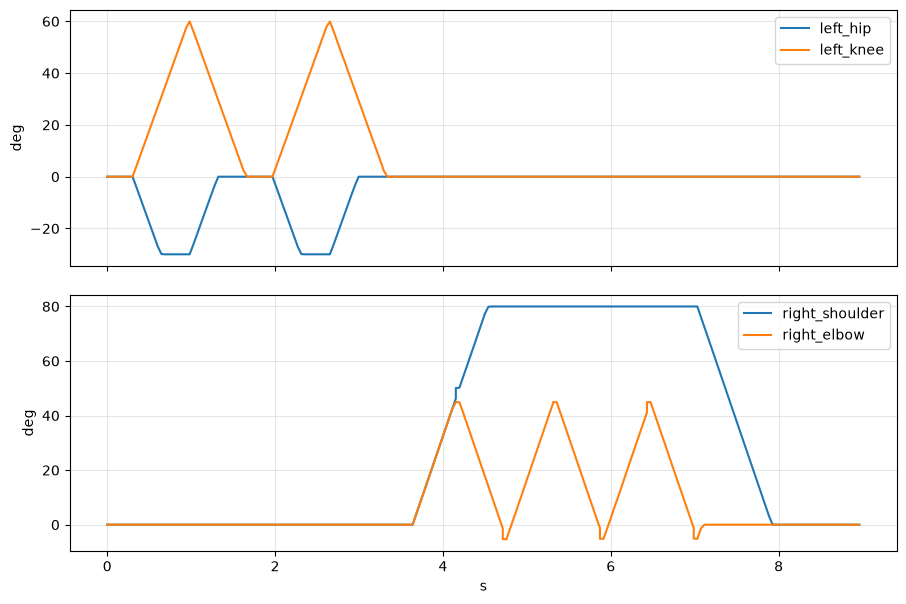

In [6]:
from coaxial.draw.figures import figure, show

t = [r['t'] for r in out.rows]
fig, (legs, arm) = figure(rows=2, sharex=True)
for joint in ('left_hip', 'left_knee'):
    legs.plot(t, [r[joint + '.deg'] for r in out.rows], label=joint)
legs.set_ylabel('deg')
legs.legend(loc='upper right')
for joint in ('right_shoulder', 'right_elbow'):
    arm.plot(t, [r[joint + '.deg'] for r in out.rows], label=joint)
arm.set_ylabel('deg')
arm.set_xlabel('s')
arm.legend(loc='upper right')
show(fig)

## 5 When the model is wrong

Checked before anything arms: a near miss comes back as the name meant, a target outside the range is refused - one line for the model to try again with.

In [7]:
from coaxial.errors import RigError

refusals = []
for wrong in ('1 left_kne=40', '1 left_knee=120', '1 left_knee=40 left_knee.degg.H=30'):
    try:
        body.run(wrong)
    except RigError as exc:
        refusals.append(str(exc).splitlines()[-1])
        print('%-36s -> %s' % (wrong, refusals[-1]))

1 left_kne=40                        -> row 0: nothing reads left_kne - did you mean left_knee?
1 left_knee=120                      -> row 0: left_knee=120 is outside -90..90
1 left_knee=40 left_knee.degg.H=30   -> row 0: no channel left_knee.degg to test - did you mean left_knee.deg?


## 6 Through the board chat

The `program` tool is what the local model calls: `op=card`, then `op=run` with its answer. The same on a stand-in session, as the model sees it.

In [8]:
from coaxial.simulated.board import SimulatedSession
from coaxial_mcp.tools import program

session = SimulatedSession(port='AX')
card = program(session, op='card')
answer = program(session, op='run', text='0.5 left_knee=30 right_knee=30\n0.5 left_knee=0 right_knee=0')
print(answer)
session.body.nodes.close()
nodes.close()

done after 0.94 s, 2 steps
  row 0 0.47 s time
  row 1 0.47 s time
  end: left_knee.deg 0, right_knee.deg 0


In [9]:
device.close()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 7 Results

In [10]:
print('1. nodes      %d, one body; %d channels offered' % (len(nodes), offered))
print('2. the prompt %d characters for %d joints' % (len(told), len(body.joints)))
print('3. the run    %s, %d steps, %.1f s' % (out.status, len(out.steps), sum(s[3] for s in out.steps)))
print('4. refused    %d of 3, each in a line' % len(refusals))

1. nodes      20, one body; 1860 channels offered
2. the prompt 805 characters for 20 joints
3. the run    done, 17 steps, 9.0 s
4. refused    3 of 3, each in a line


- The model writes lines, not code: the sequencer is the only thing that runs.
- A wrong answer costs one line back; a joint past its range trips; cleanup always runs.

**Bench.** Discover on each bus through the broker; arming empty (the STO chain released); each joint commissioned and its `span` set before a model drives it.

## References

* `host/coaxial/nodes/` - `Node`, `Nodes`: boards as IO nodes, capabilities first
* `host/coaxial/control/body.py` - `Body`: a joint feedback per node; `prompt`, `run`
* `host/coaxial/control/sequencer.py` - lines or tables; `check`, `summary`, `GRAMMAR`
* `host/coaxial_mcp/tools.py` - `program`: the board-chat tool